In [230]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [231]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [232]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/4824paso/4824pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 43
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,0.206890
2014-07-06 10:00:00,1.283232,0.117744
2014-07-06 11:00:00,1.052817,0.130165
2014-07-06 12:00:00,0.877262,-0.036042
2014-07-06 13:00:00,0.624902,-0.230041


In [233]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/4824paso/4824pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 43
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.028903
2014-07-06 10:00:00,1.283232,-0.060823
2014-07-06 11:00:00,1.052817,-0.083626
2014-07-06 12:00:00,0.877262,-0.091159
2014-07-06 13:00:00,0.624902,-0.115420


In [234]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/4824paso/4824pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 43
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,0.199350
2014-07-06 10:00:00,1.283232,0.139923
2014-07-06 11:00:00,1.052817,0.137157
2014-07-06 12:00:00,0.877262,0.090117
2014-07-06 13:00:00,0.624902,0.019414


In [235]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/4824paso/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.073292
2014-07-06 10:00:00,1.283232,-0.106070
2014-07-06 11:00:00,1.052817,-0.075329
2014-07-06 12:00:00,0.877262,-0.146368
2014-07-06 13:00:00,0.624902,-0.231192


In [236]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/4824paso/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,0.826216
2014-07-06 10:00:00,1.283232,0.491225
2014-07-06 11:00:00,1.052817,0.850267
2014-07-06 12:00:00,0.877262,0.750340
2014-07-06 13:00:00,0.624902,0.040241


In [237]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/4824paso/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 4468 - 4337 - 21
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,0.133422
2014-07-06 10:00:00,1.283232,0.112485
2014-07-06 11:00:00,1.052817,0.131471
2014-07-06 12:00:00,0.877262,0.095116
2014-07-06 13:00:00,0.624902,0.035471


## MLP ##

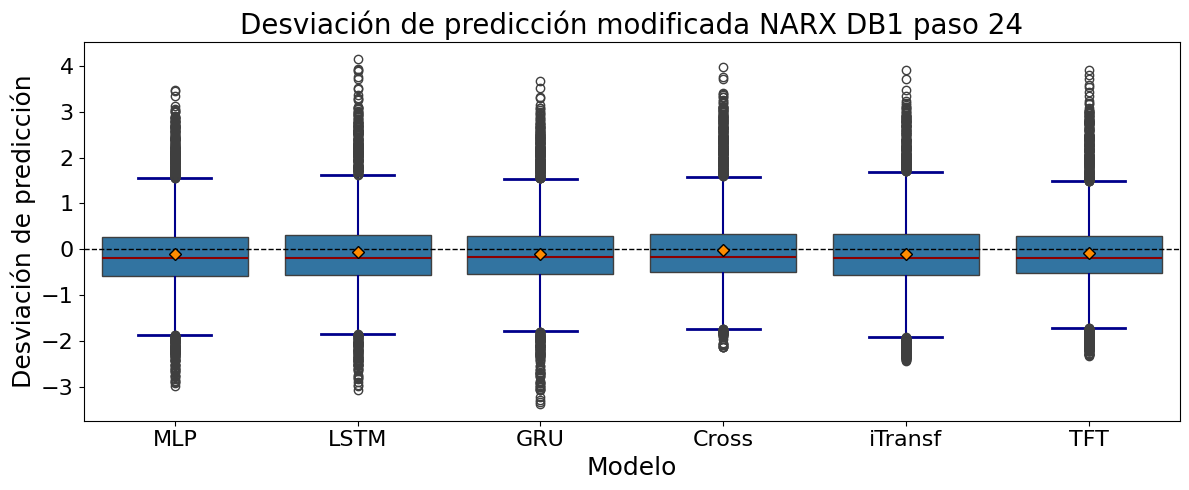

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción modificada NARX DB1 paso 24', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda


plt.tight_layout()
plt.show()


# Graficos Q-Q

In [239]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-07-06 09:00:00,1.087315,1.323107,1.094855,1.367496,0.467988,1.160783
2014-07-06 10:00:00,1.165488,1.344055,1.143309,1.389303,0.792007,1.170748
2014-07-06 11:00:00,0.922651,1.136443,0.915660,1.128146,0.202550,0.921345
2014-07-06 12:00:00,0.913304,0.968421,0.787144,1.023630,0.126922,0.782146
2014-07-06 13:00:00,0.854942,0.740322,0.605488,0.856094,0.584661,0.589431


In [240]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [241]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-08-26 05:00:00,-0.308081,-0.301847,-0.195721,-0.267928,-0.425890,-0.283218
2014-10-31 23:00:00,-0.015888,-0.040684,-0.143324,0.190084,0.097434,-0.200728
2014-11-13 01:00:00,-0.331058,-0.442682,-0.259125,-0.327728,-0.429106,-0.379522
2014-12-14 02:00:00,1.255101,1.324903,1.366325,1.350518,1.737937,1.400846
2014-12-06 23:00:00,-0.330423,-0.520823,-0.719124,-0.337270,-0.358482,-0.479491


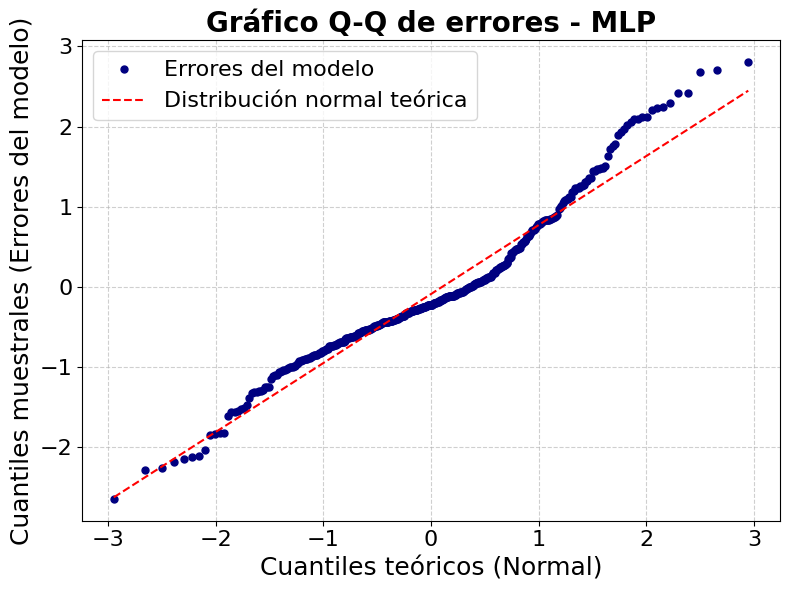

In [242]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


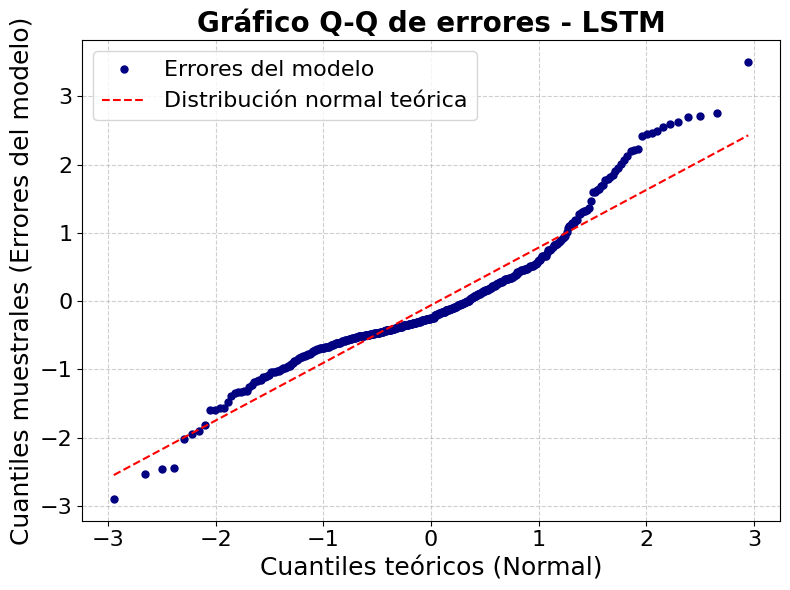

In [243]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


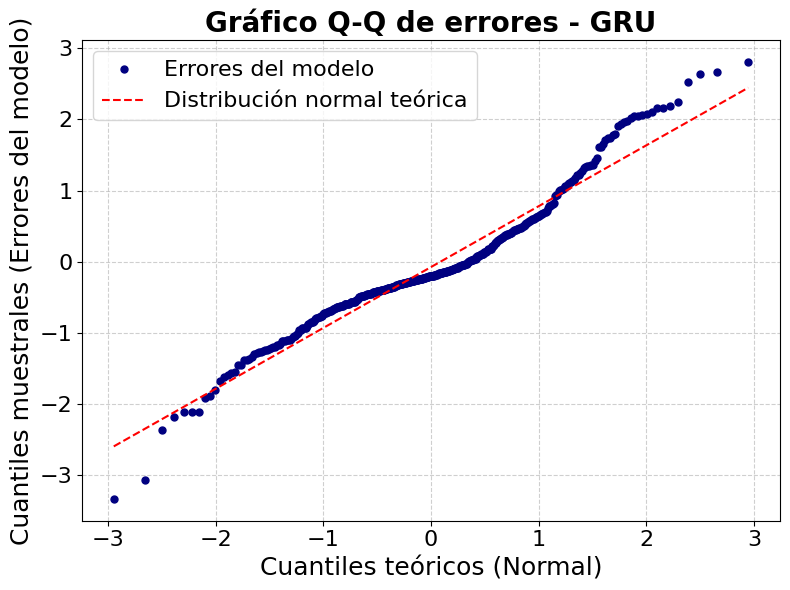

In [244]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


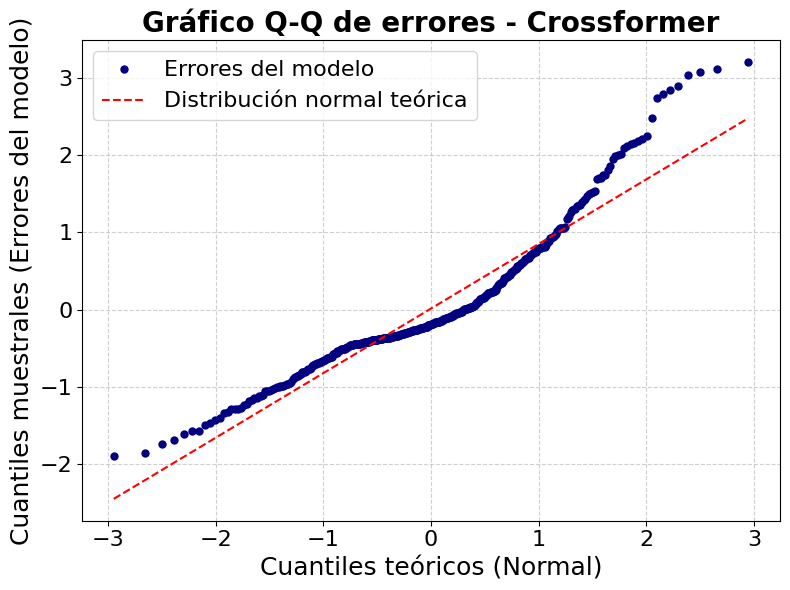

In [245]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


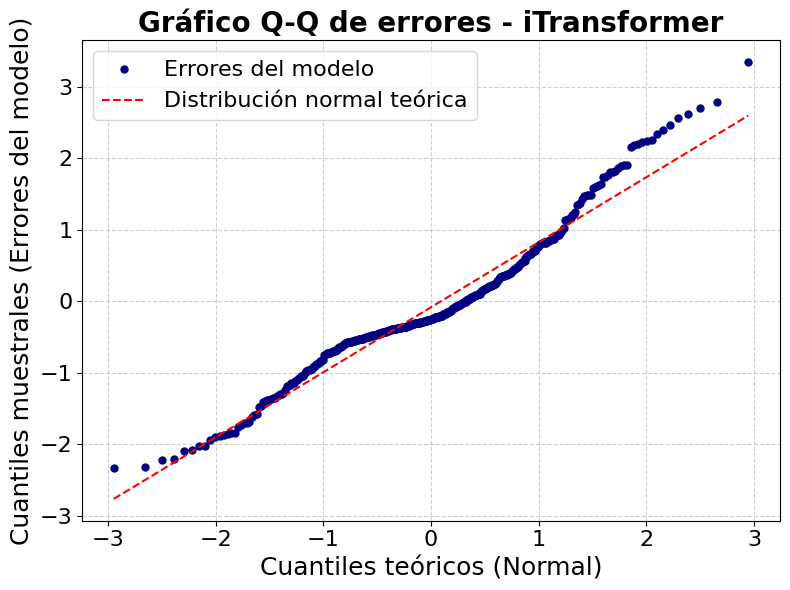

In [246]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


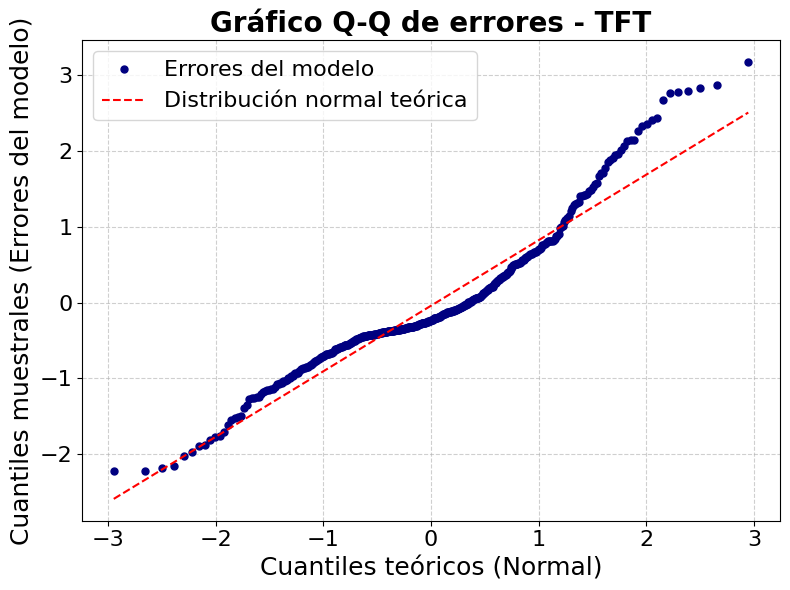

In [247]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

In [248]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

meses = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
def formatear_mes(x, pos):
    fecha = mdates.num2date(x)
    return meses.get(fecha.month, '')

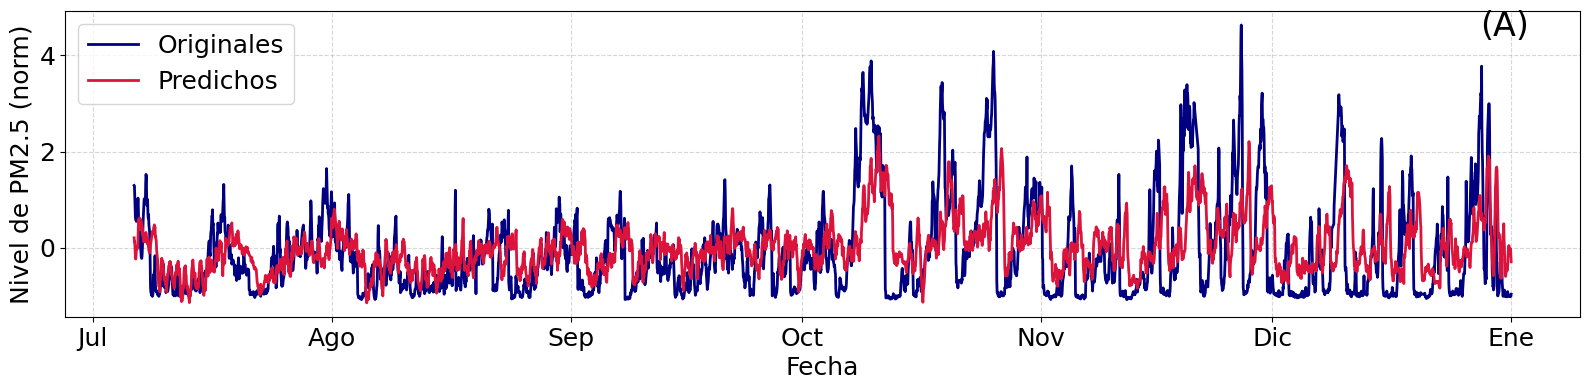

In [249]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosMLP

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


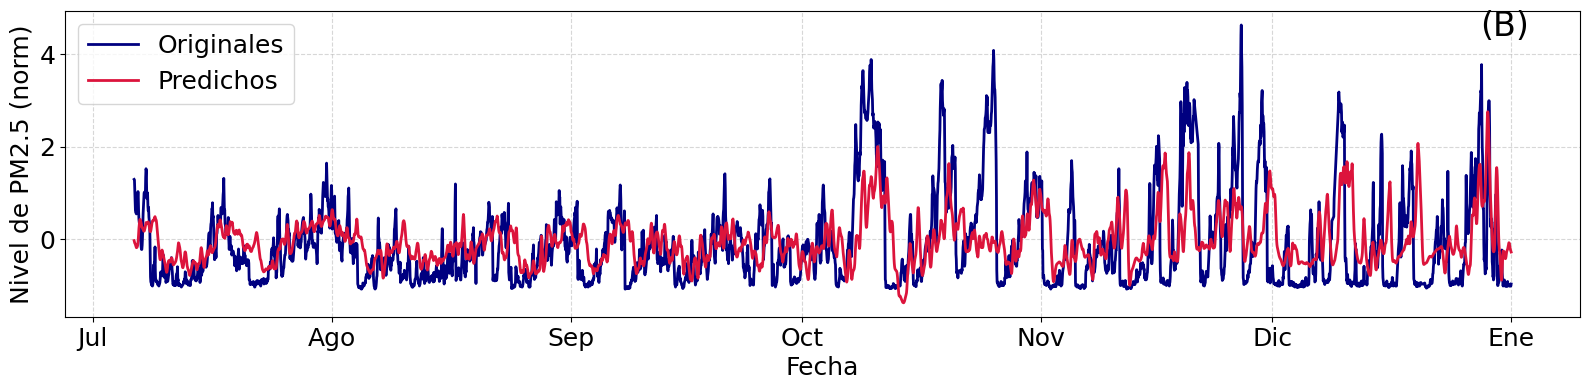

In [250]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosLSTM

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


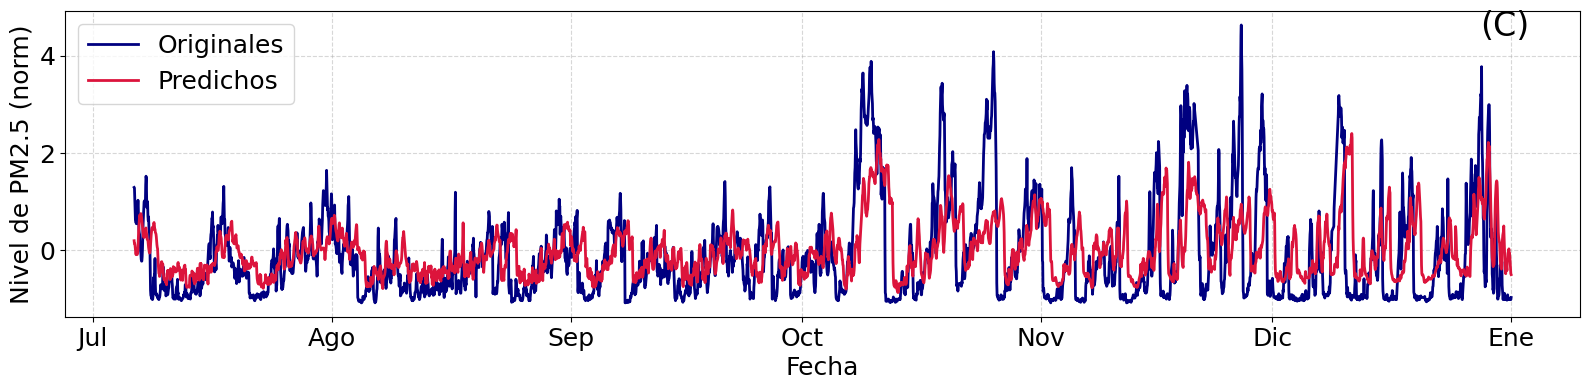

In [251]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosGRU

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


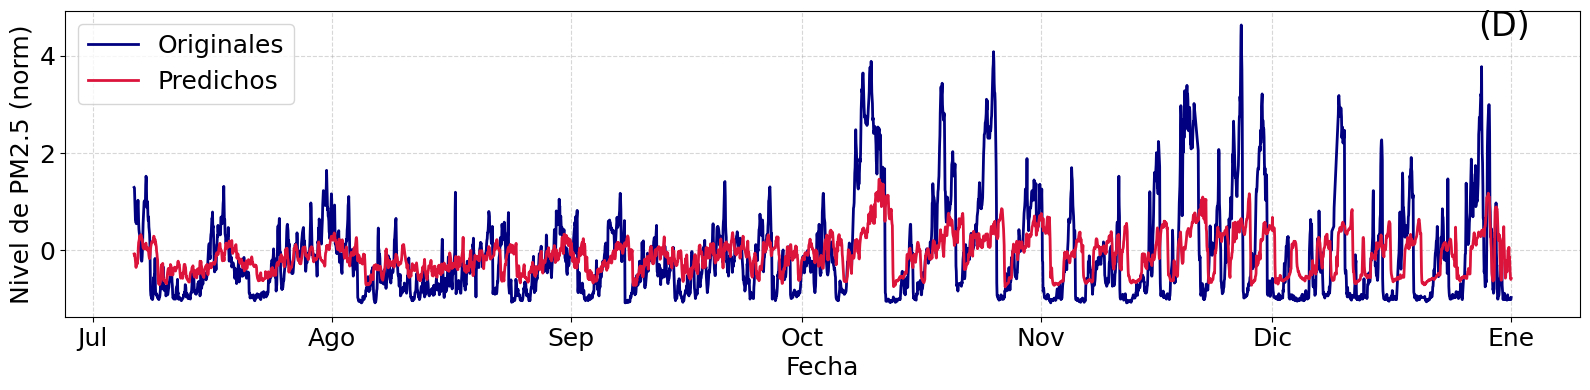

In [252]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosCross

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


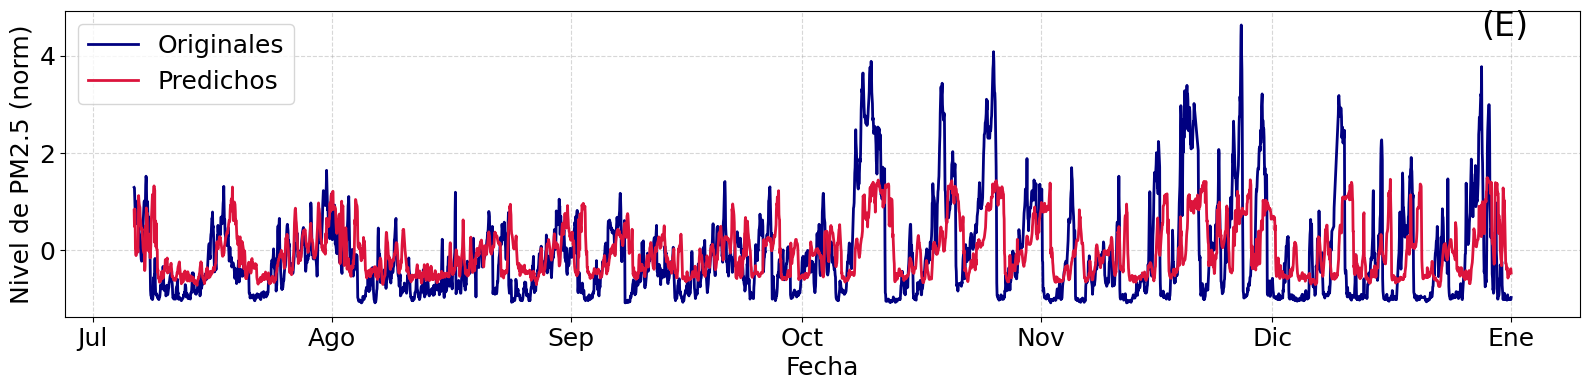

In [253]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosI

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


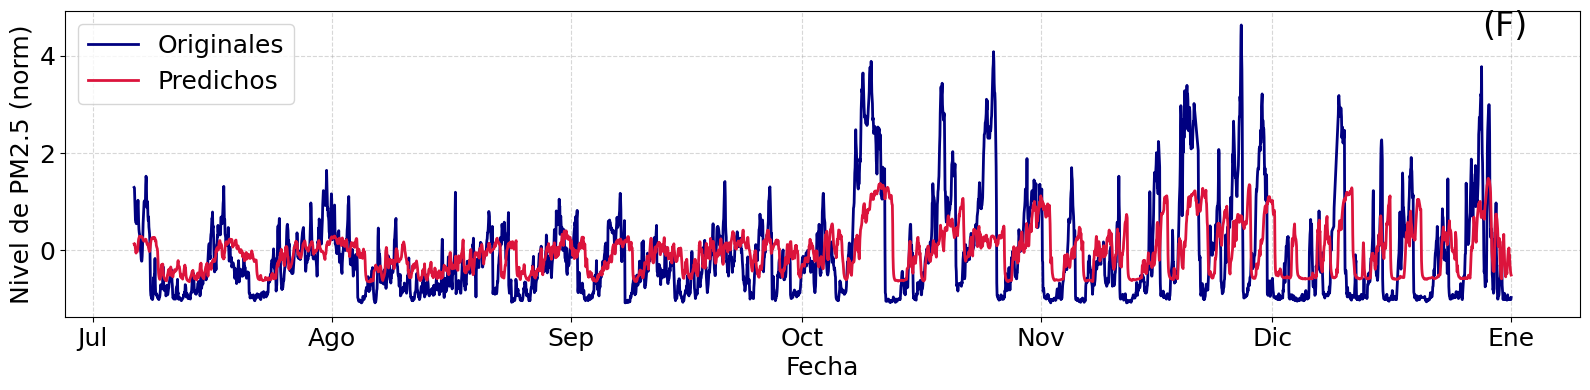

In [254]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosTFT

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


# Métricas

In [255]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [256]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8090478073532796
RMSE: 0.899470848528889
MAE: 0.6649513281188834
SMAPE: 1.233438232908734
IA: 0.4112499527469232


In [257]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8130392752713883
RMSE: 0.9016869053454133
MAE: 0.6580182027760224
SMAPE: 1.197964182049175
IA: 0.4099941910208518


In [258]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7919384645682579
RMSE: 0.8899092451302312
MAE: 0.6471726850529794
SMAPE: 1.1513927166840023
IA: 0.4419151179581051


In [259]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7832292508610315
RMSE: 0.8850024016131434
MAE: 0.6455922475754803
SMAPE: 1.2226911660039221
IA: 0.38105015632999995


In [260]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8804272651827678
RMSE: 0.9383108574362591
MAE: 0.6950538548670213
SMAPE: 1.185640981291423
IA: 0.40581555502642863


In [261]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8104391993372438
RMSE: 0.9002439665653105
MAE: 0.6590511859716685
SMAPE: 1.2089263230165843
IA: 0.40157196379509175


# Pruebas de significación

In [262]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [263]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP48:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM48:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU48:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross48:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf48:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT48:", p)


MLP48: 4.329503177005182e-10
LSTM48: 1.0485690863351085e-07
GRU48: 2.8655665795112138e-08
Cross48: 1.4536371625134375e-07
iTransf48: 1.7345510872229118e-07
TFT48: 1.0503998438773556e-08


In [264]:
datosMLPO = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/24pasos_mlp_pollution.csv')

datosMLPO['date'] = pd.to_datetime(datosMLPO['Unnamed: 0'])
datosMLPO = datosMLPO.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosMLPO = datosMLPO.iloc[corte:]

# Se establece la columna date como index
datosMLPO.set_index('date', inplace=True)

datosMLPO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.420798
2014-07-04 22:00:00,0.559069,0.555358
2014-07-04 23:00:00,0.613930,0.599092
2014-07-05 00:00:00,0.745596,0.726853
2014-07-05 01:00:00,0.789484,0.605953


In [265]:
datosLSTMO = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/24pasos_lstm_pollution.csv')

datosLSTMO['date'] = pd.to_datetime(datosLSTMO['Unnamed: 0'])
datosLSTMO = datosLSTMO.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosLSTMO = datosLSTMO.iloc[corte:]

# Se establece la columna date como index
datosLSTMO.set_index('date', inplace=True)

datosLSTMO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.264178
2014-07-04 22:00:00,0.559069,0.395738
2014-07-04 23:00:00,0.613930,0.474377
2014-07-05 00:00:00,0.745596,0.483577
2014-07-05 01:00:00,0.789484,0.412241


In [266]:
datosGRUO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/24pasos_gru_pollution.csv')

datosGRUO['date'] = pd.to_datetime(datosGRUO['Unnamed: 0'])
datosGRUO = datosGRUO.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosGRUO = datosGRUO.iloc[corte:]

# Se establece la columna date como index
datosGRUO.set_index('date', inplace=True)

datosGRUO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.334962
2014-07-04 22:00:00,0.559069,0.437290
2014-07-04 23:00:00,0.613930,0.478565
2014-07-05 00:00:00,0.745596,0.508283
2014-07-05 01:00:00,0.789484,0.455417


In [267]:
datosCrossO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/crossformerPollution.csv')

datosCrossO['date'] = pd.to_datetime(datosCrossO['Unnamed: 0'])
datosCrossO = datosCrossO.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCrossO.set_index('date', inplace=True)

datosCrossO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.200241
2014-07-04 22:00:00,0.559069,0.291358
2014-07-04 23:00:00,0.613930,0.293672
2014-07-05 00:00:00,0.745596,0.329007
2014-07-05 01:00:00,0.789484,0.261832


In [268]:
datosIO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/itransformerPollution.csv')

datosIO['date'] = pd.to_datetime(datosIO['Unnamed: 0'])
datosIO = datosIO.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosIO.set_index('date', inplace=True)

datosIO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.434569
2014-07-04 22:00:00,0.559069,0.794278
2014-07-04 23:00:00,0.613930,0.798075
2014-07-05 00:00:00,0.745596,0.968433
2014-07-05 01:00:00,0.789484,0.966470


In [269]:
datosTFTO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/tftPollution.csv')

datosTFTO['date'] = pd.to_datetime(datosTFTO['Unnamed: 0'])
datosTFTO = datosTFTO.drop(columns=['Unnamed: 0'])

corte = 4468 - 4337 - 21
datosTFTO = datosTFTO.iloc[corte:]

# Se establece la columna date como index
datosTFTO.set_index('date', inplace=True)

datosTFTO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.161209
2014-07-04 22:00:00,0.559069,0.230772
2014-07-04 23:00:00,0.613930,0.283441
2014-07-05 00:00:00,0.745596,0.332517
2014-07-05 01:00:00,0.789484,0.273267


In [270]:
rMLPO = pd.DataFrame(datosMLPO['Originales'] - datosMLPO['Predichos'], columns=['MLPO'])
rLSTMO = pd.DataFrame(datosLSTMO['Originales'] - datosLSTMO['Predichos'], columns=['LSTMO'])
rGRUO = pd.DataFrame(datosGRUO['Originales'] - datosGRUO['Predichos'], columns=['GRUO'])
rCrossO = pd.DataFrame(datosCrossO['Originales'] - datosCrossO['Predichos'], columns=['CrossformerO'])
rIO = pd.DataFrame(datosIO['Originales'] - datosIO['Predichos'], columns=['iTransformerO'])
rTFTO = pd.DataFrame(datosTFTO['Originales'] - datosTFTO['Predichos'], columns=['TFTO'])

final2 = final.join(rMLPO, how='outer').join(rLSTMO, how='outer').join(rGRUO, how='outer').join(rCrossO, how='outer').join(rIO, how='outer').join(rTFTO, how='outer')
final2.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLPO,LSTMO,GRUO,CrossformerO,iTransformerO,TFTO
date,,,,,,,,,,,,
2014-07-04 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.368686,0.525306,0.454523,0.589244,0.354916,0.628276
2014-07-04 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.003711,0.163331,0.121779,0.267711,-0.235209,0.328297
2014-07-04 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.014838,0.139552,0.135364,0.320258,-0.184146,0.330489
2014-07-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.018743,0.262019,0.237313,0.416589,-0.222837,0.413079
2014-07-05 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.183532,0.377243,0.334067,0.527653,-0.176985,0.516217


In [271]:
finalTotal2 = final2.isna().sum()
print(finalTotal2)
final2 = final2.dropna()
final2.head()

MLP              3894
LSTM             3894
GRU              3894
Crossformer      3894
iTransformer     3894
TFT              3894
MLPO                0
LSTMO               0
GRUO                0
CrossformerO        0
iTransformerO       0
TFTO                0
dtype: int64


,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLPO,LSTMO,GRUO,CrossformerO,iTransformerO,TFTO
date,,,,,,,,,,,,
2014-07-06 17:00:00,0.638794,0.815719,0.700485,0.919344,0.549985,0.668480,0.721994,0.647809,0.609078,0.816170,0.621823,0.640959
2014-07-06 23:00:00,-0.011624,0.456563,0.169423,0.419024,-0.545339,0.349337,0.273372,0.166429,0.066692,0.378067,0.075169,0.240679
2014-07-07 02:00:00,-0.289832,-0.058827,-0.395457,0.035298,-0.580775,0.037294,-0.185111,-0.240293,-0.350643,-0.024170,-0.638590,-0.006976
2014-07-07 08:00:00,-0.736383,-0.517598,-0.907415,-0.489908,-0.676337,-0.505742,-0.715668,-0.533233,-0.621329,-0.449972,-1.116262,-0.242833
2014-07-07 18:00:00,0.886911,0.796682,0.686006,0.933414,1.421732,0.805592,0.793042,0.760516,0.651917,0.953515,0.702204,0.974566


In [272]:
final2 = final2.loc[final.index]
final2.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLPO,LSTMO,GRUO,CrossformerO,iTransformerO,TFTO
date,,,,,,,,,,,,
2014-08-26 05:00:00,-0.308081,-0.301847,-0.195721,-0.267928,-0.425890,-0.283218,-0.400171,-0.391253,-0.346521,-0.319848,-0.328142,-0.313305
2014-10-31 23:00:00,-0.015888,-0.040684,-0.143324,0.190084,0.097434,-0.200728,0.063824,0.209885,0.050913,0.281055,0.445826,0.231963
2014-11-13 01:00:00,-0.331058,-0.442682,-0.259125,-0.327728,-0.429106,-0.379522,-0.354556,-0.414967,-0.278439,-0.304943,-0.307830,-0.377280
2014-12-14 02:00:00,1.255101,1.324903,1.366325,1.350518,1.737937,1.400846,1.210361,1.300734,1.354811,1.341292,1.610836,1.200858
2014-12-06 23:00:00,-0.330423,-0.520823,-0.719124,-0.337270,-0.358482,-0.479491,-0.374407,-0.412580,-0.541359,-0.571916,-0.988864,-0.313281


In [273]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'MLPO'),
    ('LSTM', 'LSTMO'),
    ('GRU', 'GRUO'),
    ('Crossformer', 'CrossformerO'),
    ('iTransformer', 'iTransformerO'),
    ('TFT', 'TFTO'),
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT'),
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final2[model1], final2[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs MLPO,0.18519,1.00000,1.00000
1,LSTM vs LSTMO,0.16776,1.00000,1.00000
2,GRU vs GRUO,0.00004,0.00092,0.00066
3,Crossformer vs CrossformerO,0.06747,1.00000,0.67559
4,iTransformer vs iTransformerO,0.00002,0.00035,0.00027
5,TFT vs TFTO,0.04379,0.91952,0.56923
6,MLP vs LSTM,0.33378,1.00000,1.00000
7,MLP vs GRU,0.28077,1.00000,1.00000
8,MLP vs Crossformer,0.00000,0.00000,0.00000
9,MLP vs iTransformer,0.36380,1.00000,1.00000
